# 03 — Results analysis

Reads all per-run CSVs from `output/results/03_train_models/` and summarises model performance.

In [21]:
import glob
import os
import stylia

stylia.set_style("ersilia")
nc = stylia.NamedColors()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.minor.pad"] = 1  # default is 3.5
plt.rcParams["hatch.linewidth"] = 0.4  # previous pdf hatch linewidth

RESULTS_DIR = "../results/chembl"

In [22]:
# Load and concatenate all run CSVs
files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv")))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"{len(files)} run files → {len(df)} rows")

# Map pathogen codes to full names
pathogens = pd.read_csv(
    "/home/acomajuncosa/github/chembl-antimicrobial-models/config/pathogens.csv"
)
pathogen_codes = dict(zip(pathogens["code"], pathogens["pathogen"]))

# Add compound / active counts from selected-datasets metadata
_meta = pd.read_csv(
    "/home/acomajuncosa/github/chembl-antimicrobial-models/data/processed/01b_selected_datasets.csv"
)[["pathogen", "name", "compounds", "positives"]]
df = df.merge(
    _meta, left_on=["pathogen", "dataset"], right_on=["pathogen", "name"], how="left"
).drop(columns="name")
cols = [i for i in df.columns if i not in ["compounds", "positives"]]
cols = cols[:3] + ["compounds", "positives"] + cols[3:]
df = df[cols]

# Show only performance
cols = [i for i in df.columns if "time" not in i and "onnx" not in i]
df[cols]

10 run files → 10 rows


,pathogen,dataset,mode,compounds,positives,n_train,n_test,n_pos_train,n_neg_train,n_pos_test,n_neg_test,auroc_lazy,aupr_lazy,bedroc_lazy,aupr_baseline,sensitivity,specificity,auroc_rf,auroc_lr,auroc_xgb,auroc_svc,head_score_cddd_lr,head_score_cddd_xgb,head_score_cddd_rf,head_score_cddd_svc,pooler_cddd_mode,pooler_cddd_score,head_score_chemeleon_lr,head_score_chemeleon_xgb,head_score_chemeleon_rf,head_score_chemeleon_svc,pooler_chemeleon_mode,pooler_chemeleon_score,head_score_clamp_lr,head_score_clamp_xgb,head_score_clamp_rf,head_score_clamp_svc,pooler_clamp_mode,pooler_clamp_score,head_score_morgan_lr,head_score_morgan_xgb,head_score_morgan_rf,head_score_morgan_svc,pooler_morgan_mode,pooler_morgan_score,head_score_rdkit_lr,head_score_rdkit_xgb,head_score_rdkit_rf,head_score_rdkit_svc,pooler_rdkit_mode,pooler_rdkit_score,brier_score,brier_baseline,ece,prob_active_min,prob_active_p5,prob_active_p25,prob_active_p50,prob_active_p75,prob_active_p95,prob_active_max,prob_inactive_min,prob_inactive_p5,prob_inactive_p25,prob_inactive_p50,prob_inactive_p75,prob_inactive_p95,prob_inactive_max,optimal_cutoff,calibration_y,score_active_min,score_active_p5,score_active_p25,score_active_p50,score_active_p75,score_active_p95,score_active_max,score_inactive_min,score_inactive_p5,score_inactive_p25,score_inactive_p50,score_inactive_p75,score_inactive_p95,score_inactive_max,rank_active_min,rank_active_p5,rank_active_p25,rank_active_p50,rank_active_p75,rank_active_p95,rank_active_max,rank_inactive_min,rank_inactive_p5,rank_inactive_p25,rank_inactive_p50,rank_inactive_p75,rank_inactive_p95,rank_inactive_max,lift_active_min,lift_active_p5,lift_active_p25,lift_active_p50,lift_active_p75,lift_active_p95,lift_active_max,lift_inactive_min,lift_inactive_p5,lift_inactive_p25,lift_inactive_p50,lift_inactive_p75,lift_inactive_p95,lift_inactive_max,logit_active_min,logit_active_p5,logit_active_p25,logit_active_p50,logit_active_p75,logit_active_p95,logit_active_max,logit_inactive_min,logit_inactive_p5,logit_inactive_p25,logit_inactive_p50,logit_inactive_p75,logit_inactive_p95,logit_inactive_max,ef_1pct,recall_at_1pct,ef_2pct,recall_at_2pct,ef_5pct,recall_at_5pct,ef_10pct,recall_at_10pct,ef_20pct,recall_at_20pct
0,abaumannii,G_ORG0_10.0,fast,7763,1971,6210,1553,1577,4633,394,1159,0.9299,0.8295,0.9168,0.2537,0.8223,0.8637,0.9266,NaN,0.9172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8179,0.8161,NaN,equal,0.8435,NaN,NaN,NaN,NaN,NaN,NaN,0.0886,0.1893,0.0219,0.0160,0.1311,0.4501,0.6958,0.8948,0.9801,1.0000,0.0080,0.0114,0.0223,0.0402,0.1384,0.5481,0.9857,0.3284,0.0161;0.1677;0.2637;0.2973;0.4110;0.5714;0.64...,0.0082,0.1430,0.5464,0.8033,0.9353,0.9907,0.9992,0.0002,0.0048,0.0199,0.0482,0.1710,0.6524,0.9947,0.1350,0.5646,0.7493,0.8530,0.9385,0.9863,1.0000,0.0331,0.0818,0.2066,0.3522,0.5732,0.7884,0.9871,0.0629,0.5161,1.7725,2.7398,3.5235,3.8596,3.9379,0.0316,0.0447,0.0877,0.1582,0.5452,2.1583,3.8814,-4.1215,-1.8943,-0.2002,0.8272,2.1405,3.8980,16.1181,-4.8171,-4.4670,-3.7817,-3.1738,-1.8283,0.1930,4.2298,3.6953,0.0381,3.6873,0.0736,3.7900,0.1904,3.5856,0.3579,3.2192,0.6447
1,abaumannii,G_ORG0_10.0,slow,7763,1971,6210,1553,1577,4633,394,1159,0.9329,0.8320,0.9167,0.2537,0.8706,0.8361,0.9266,NaN,0.9172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8280,0.8159,NaN,equal,0.8385,NaN,0.8079,0.7884,NaN,equal,0.8195,NaN,0.8179,0.8161,NaN,equal,0.8435,NaN,NaN,NaN,NaN,NaN,NaN,0.0874,0.1893,0.0234,0.0173,0.1175,0.4575,0.6862,0.8753,0.9672,1.0000,0.0003,0.0097,0.0194,0.0371,0.1437,0.5400,0.9843,0.2745,0.0180;0.1694;0.2584;0.3030;0.3837;0.5972;0.69...,0.0242,0.1535,0.5126,0.7475,0.9014,0.9774,0.9960,0.0022,0.0151,0.0357,0.0641,0.1773,0.6147,0.9907,0.2029,0.5497,0.7525,0.8467,0.9308,0.9815,0.9987,0.0292,0.1054,0.2185,0.3457,0.5703,0.7893,0.9875,0.0679,0.4626,1.8015,2.7022,3.4468,3.8089,3.9379,0.0011,0.0382,0.0763,0.1462,0.5659,2.1265,3.8761,-4.0424,-2.0166,-0.1704,0.7824,1.9486,3.3855,16.1181,-8.1514,-4.6246,-3.9242,-3.2559,-1.7848,0.1604,4.1395,3.6953,

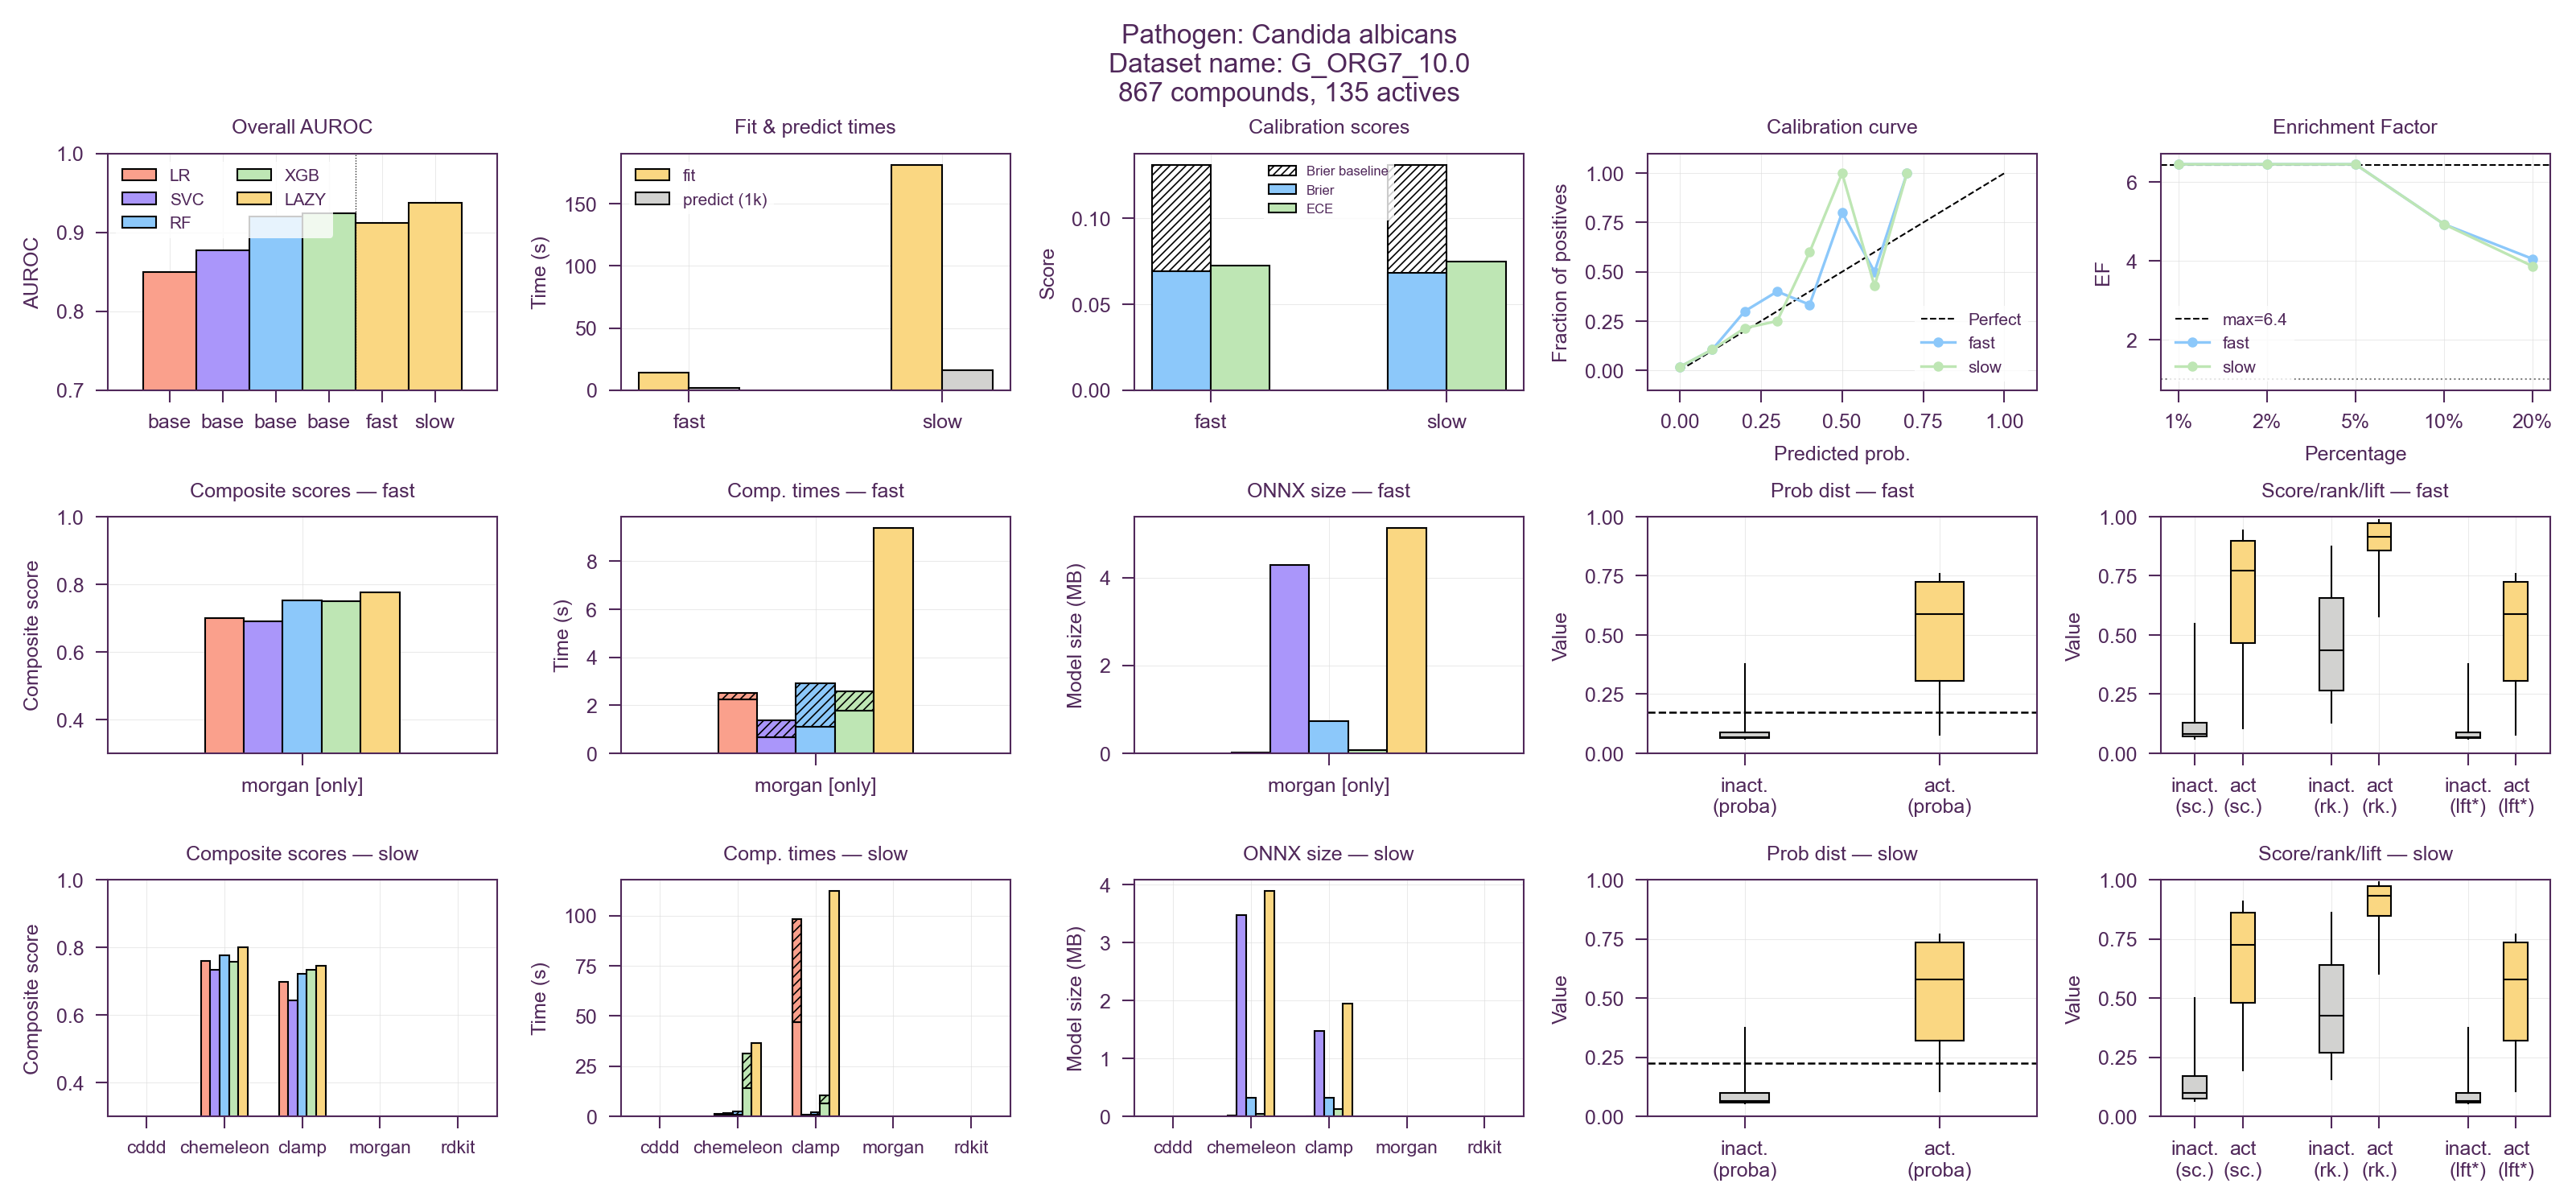

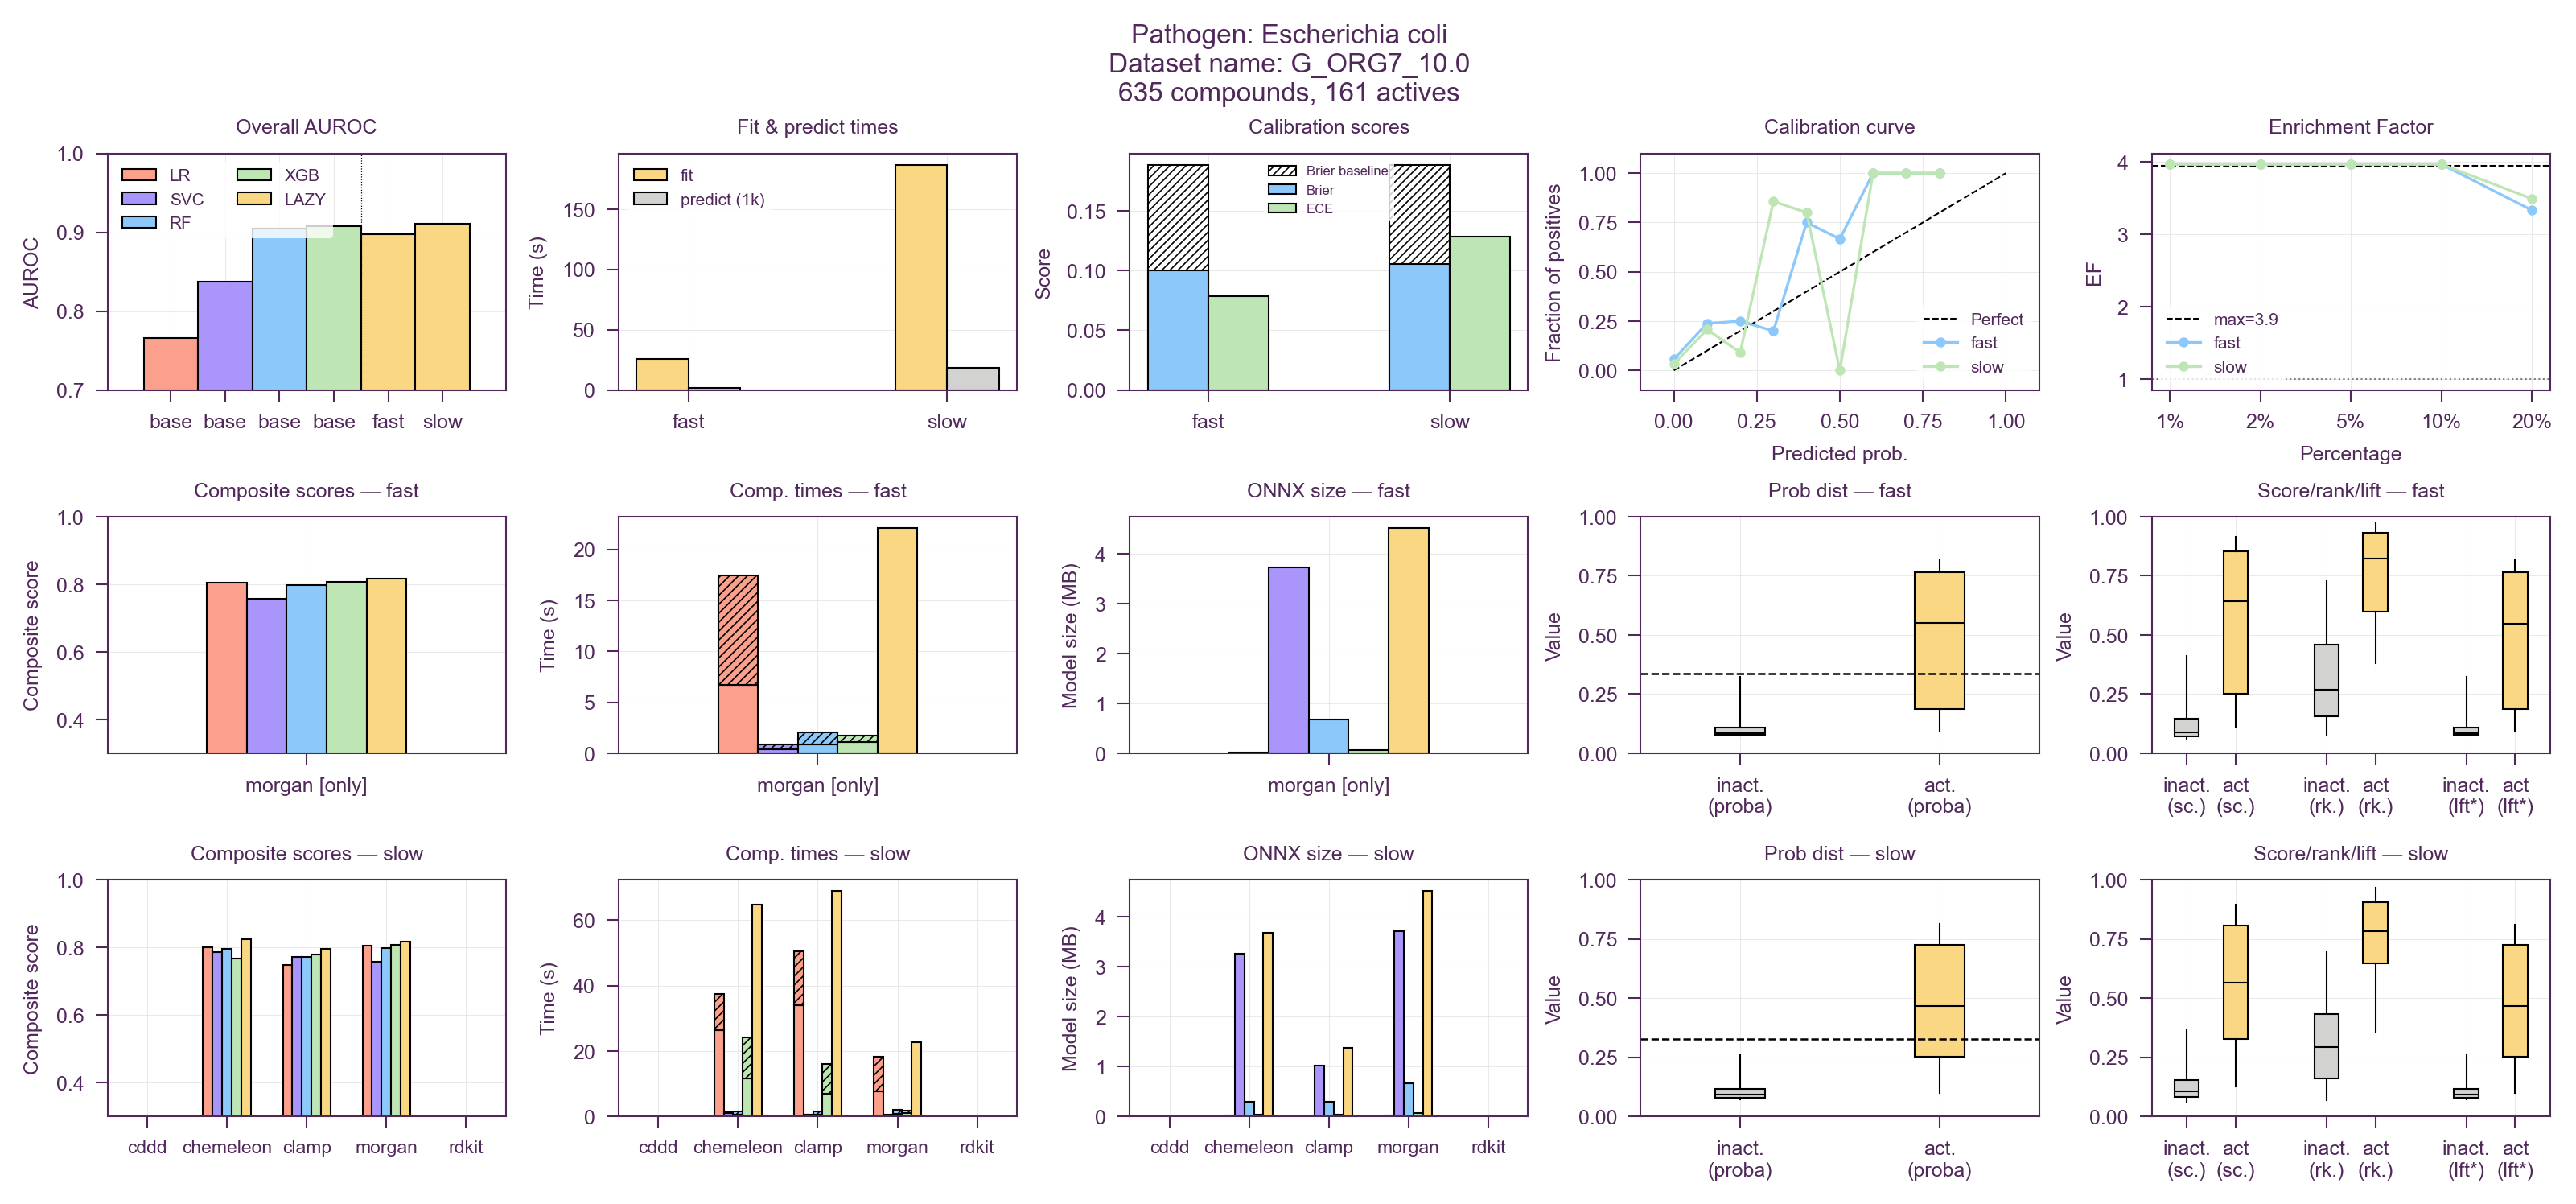

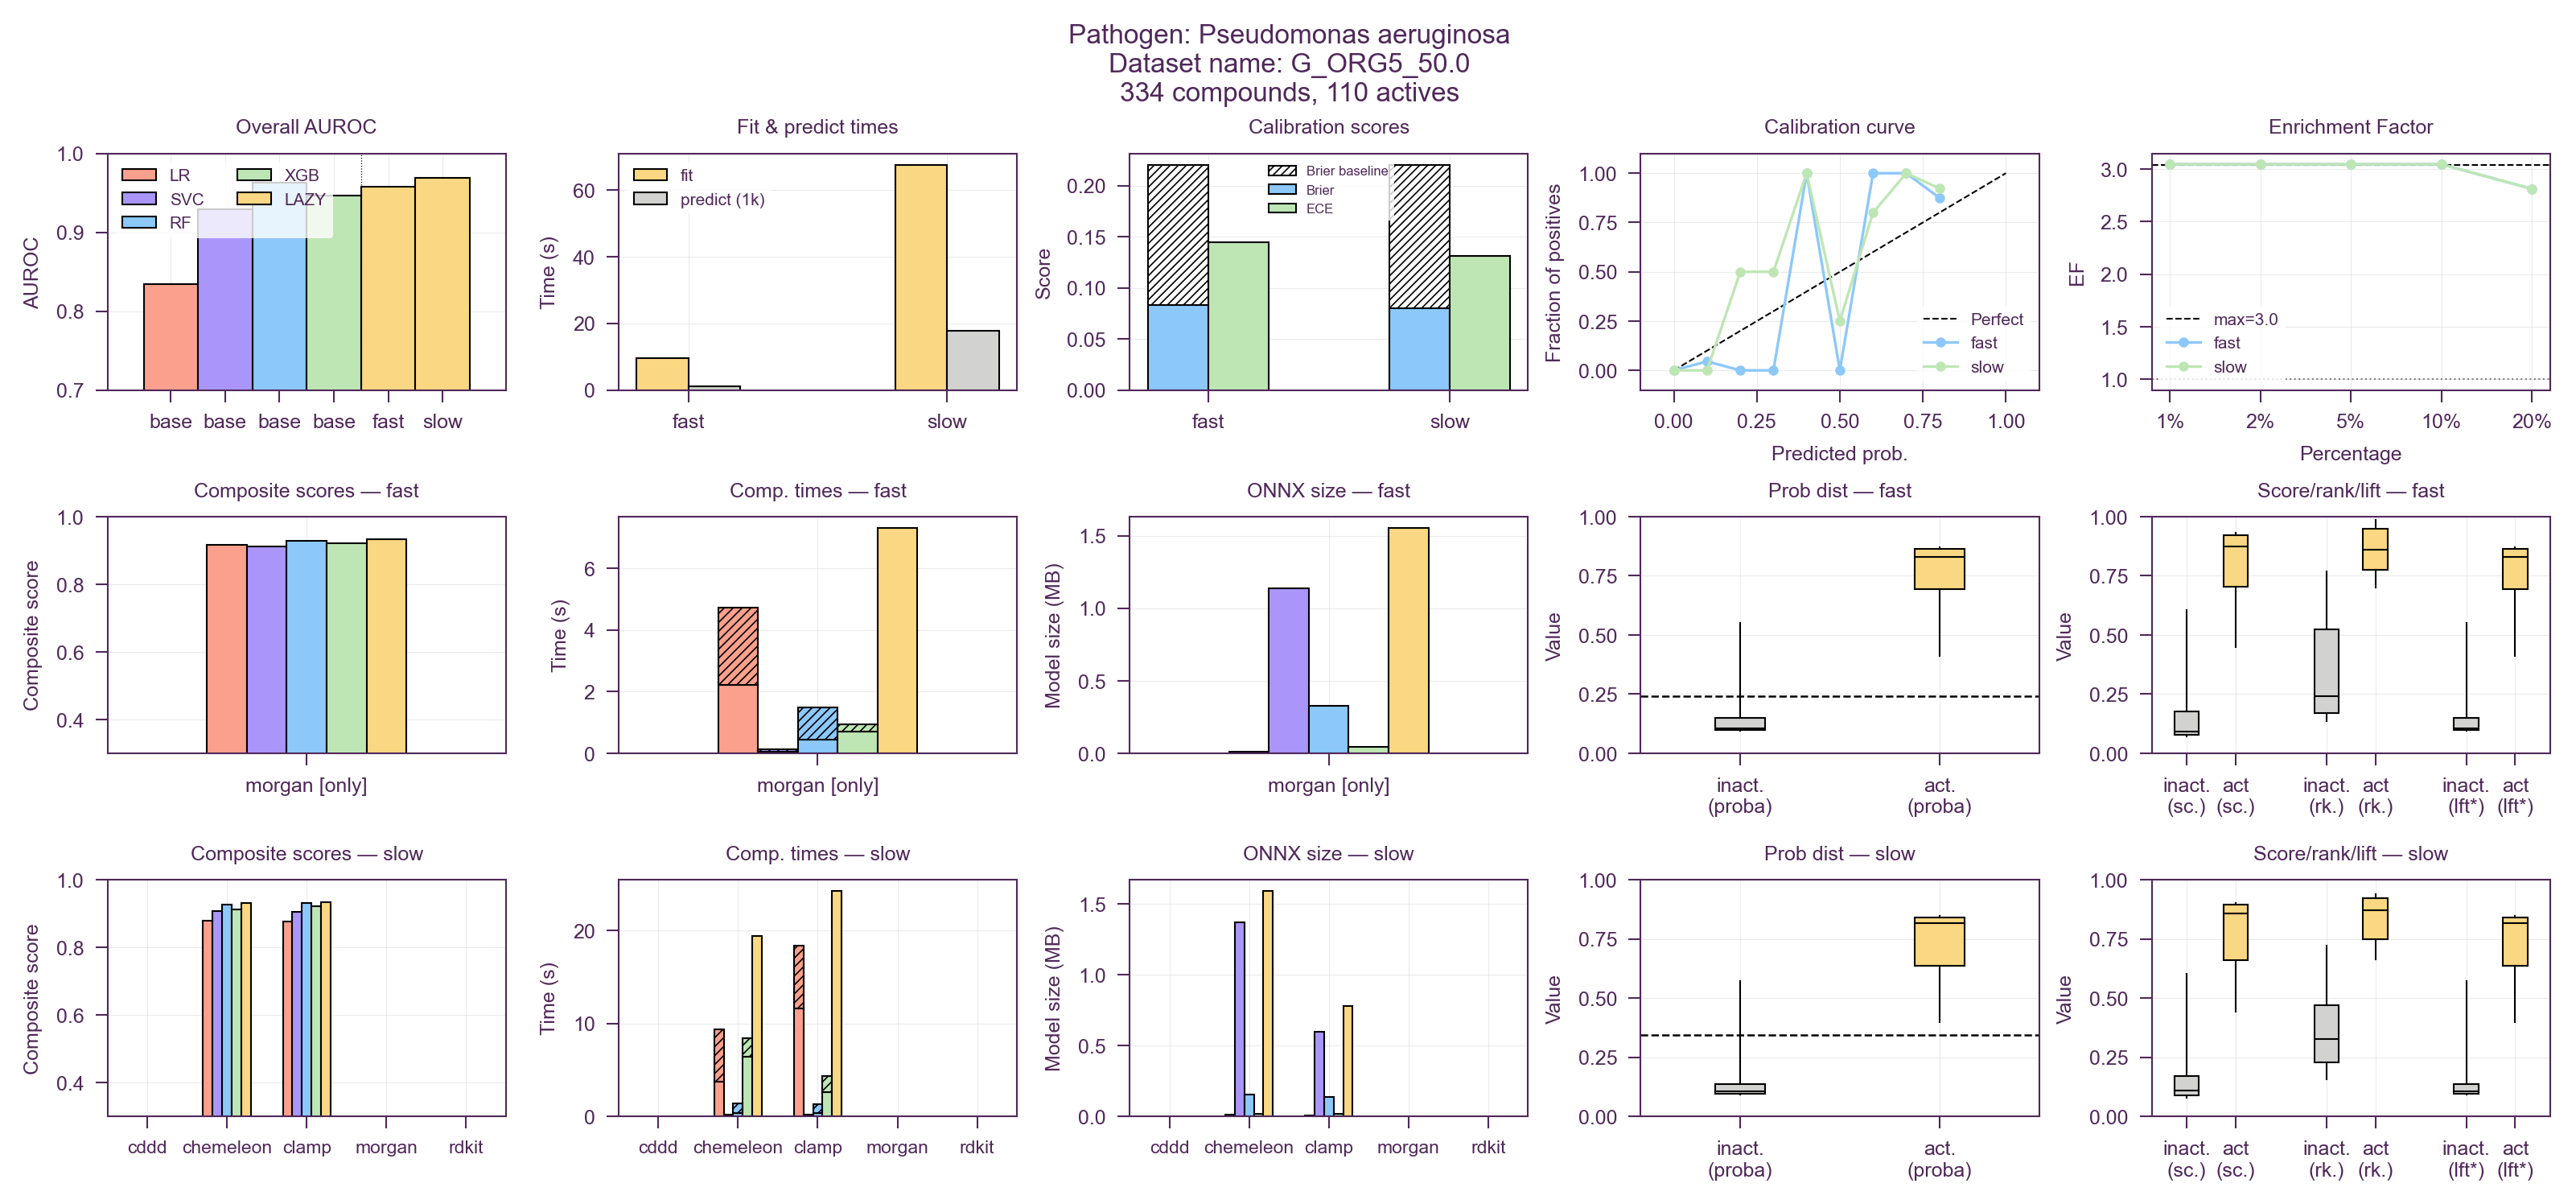

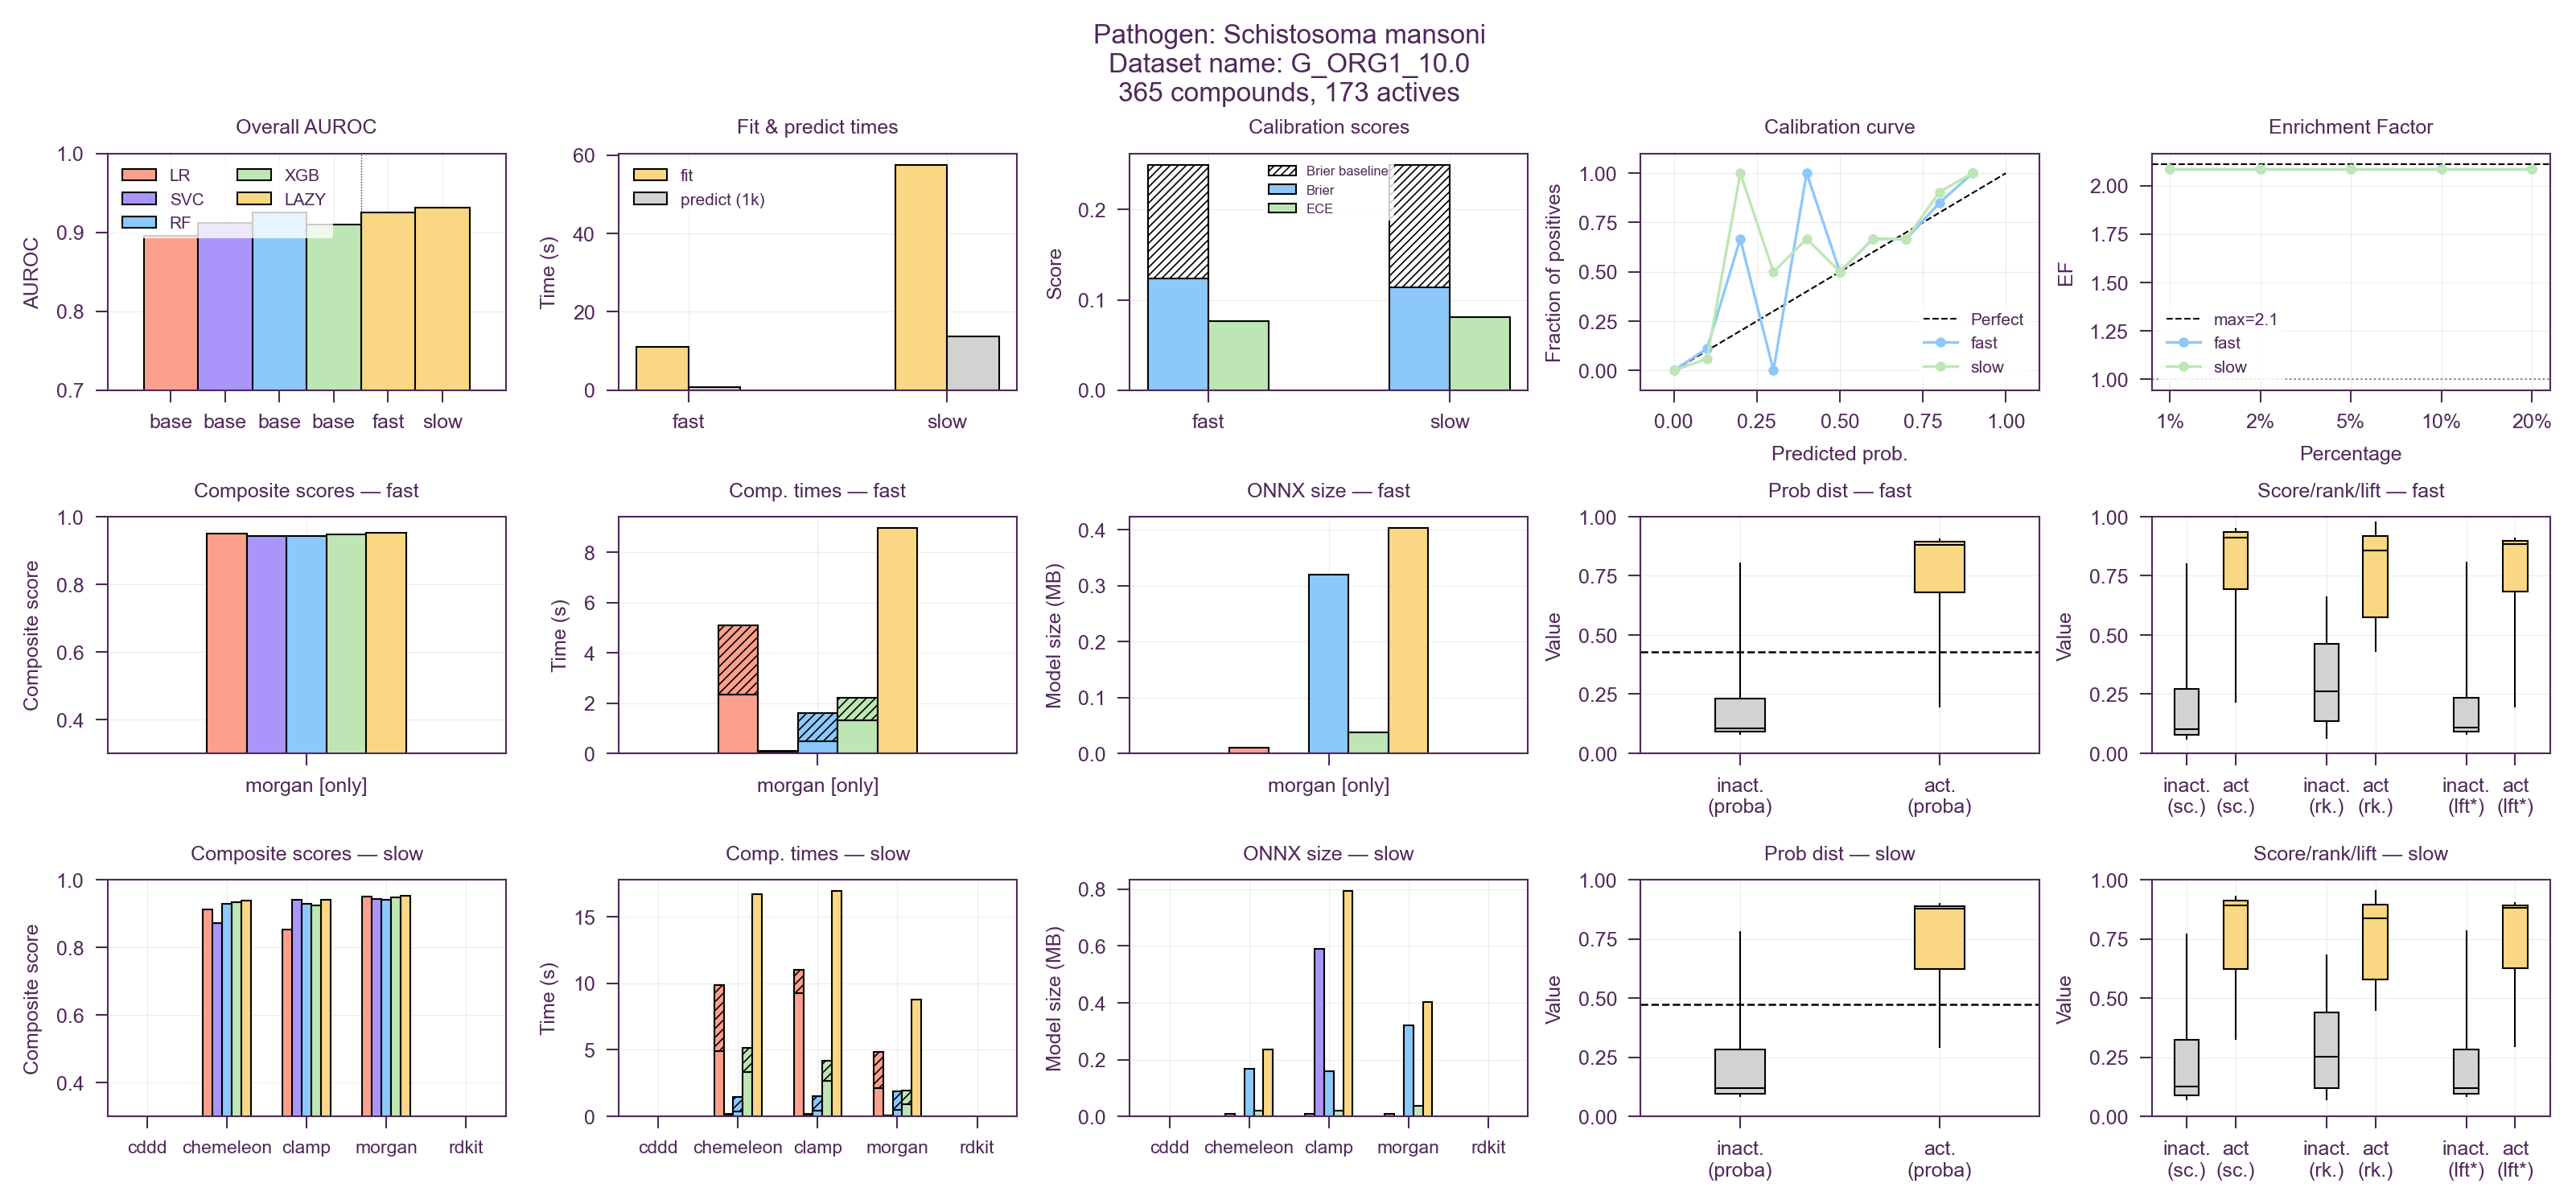

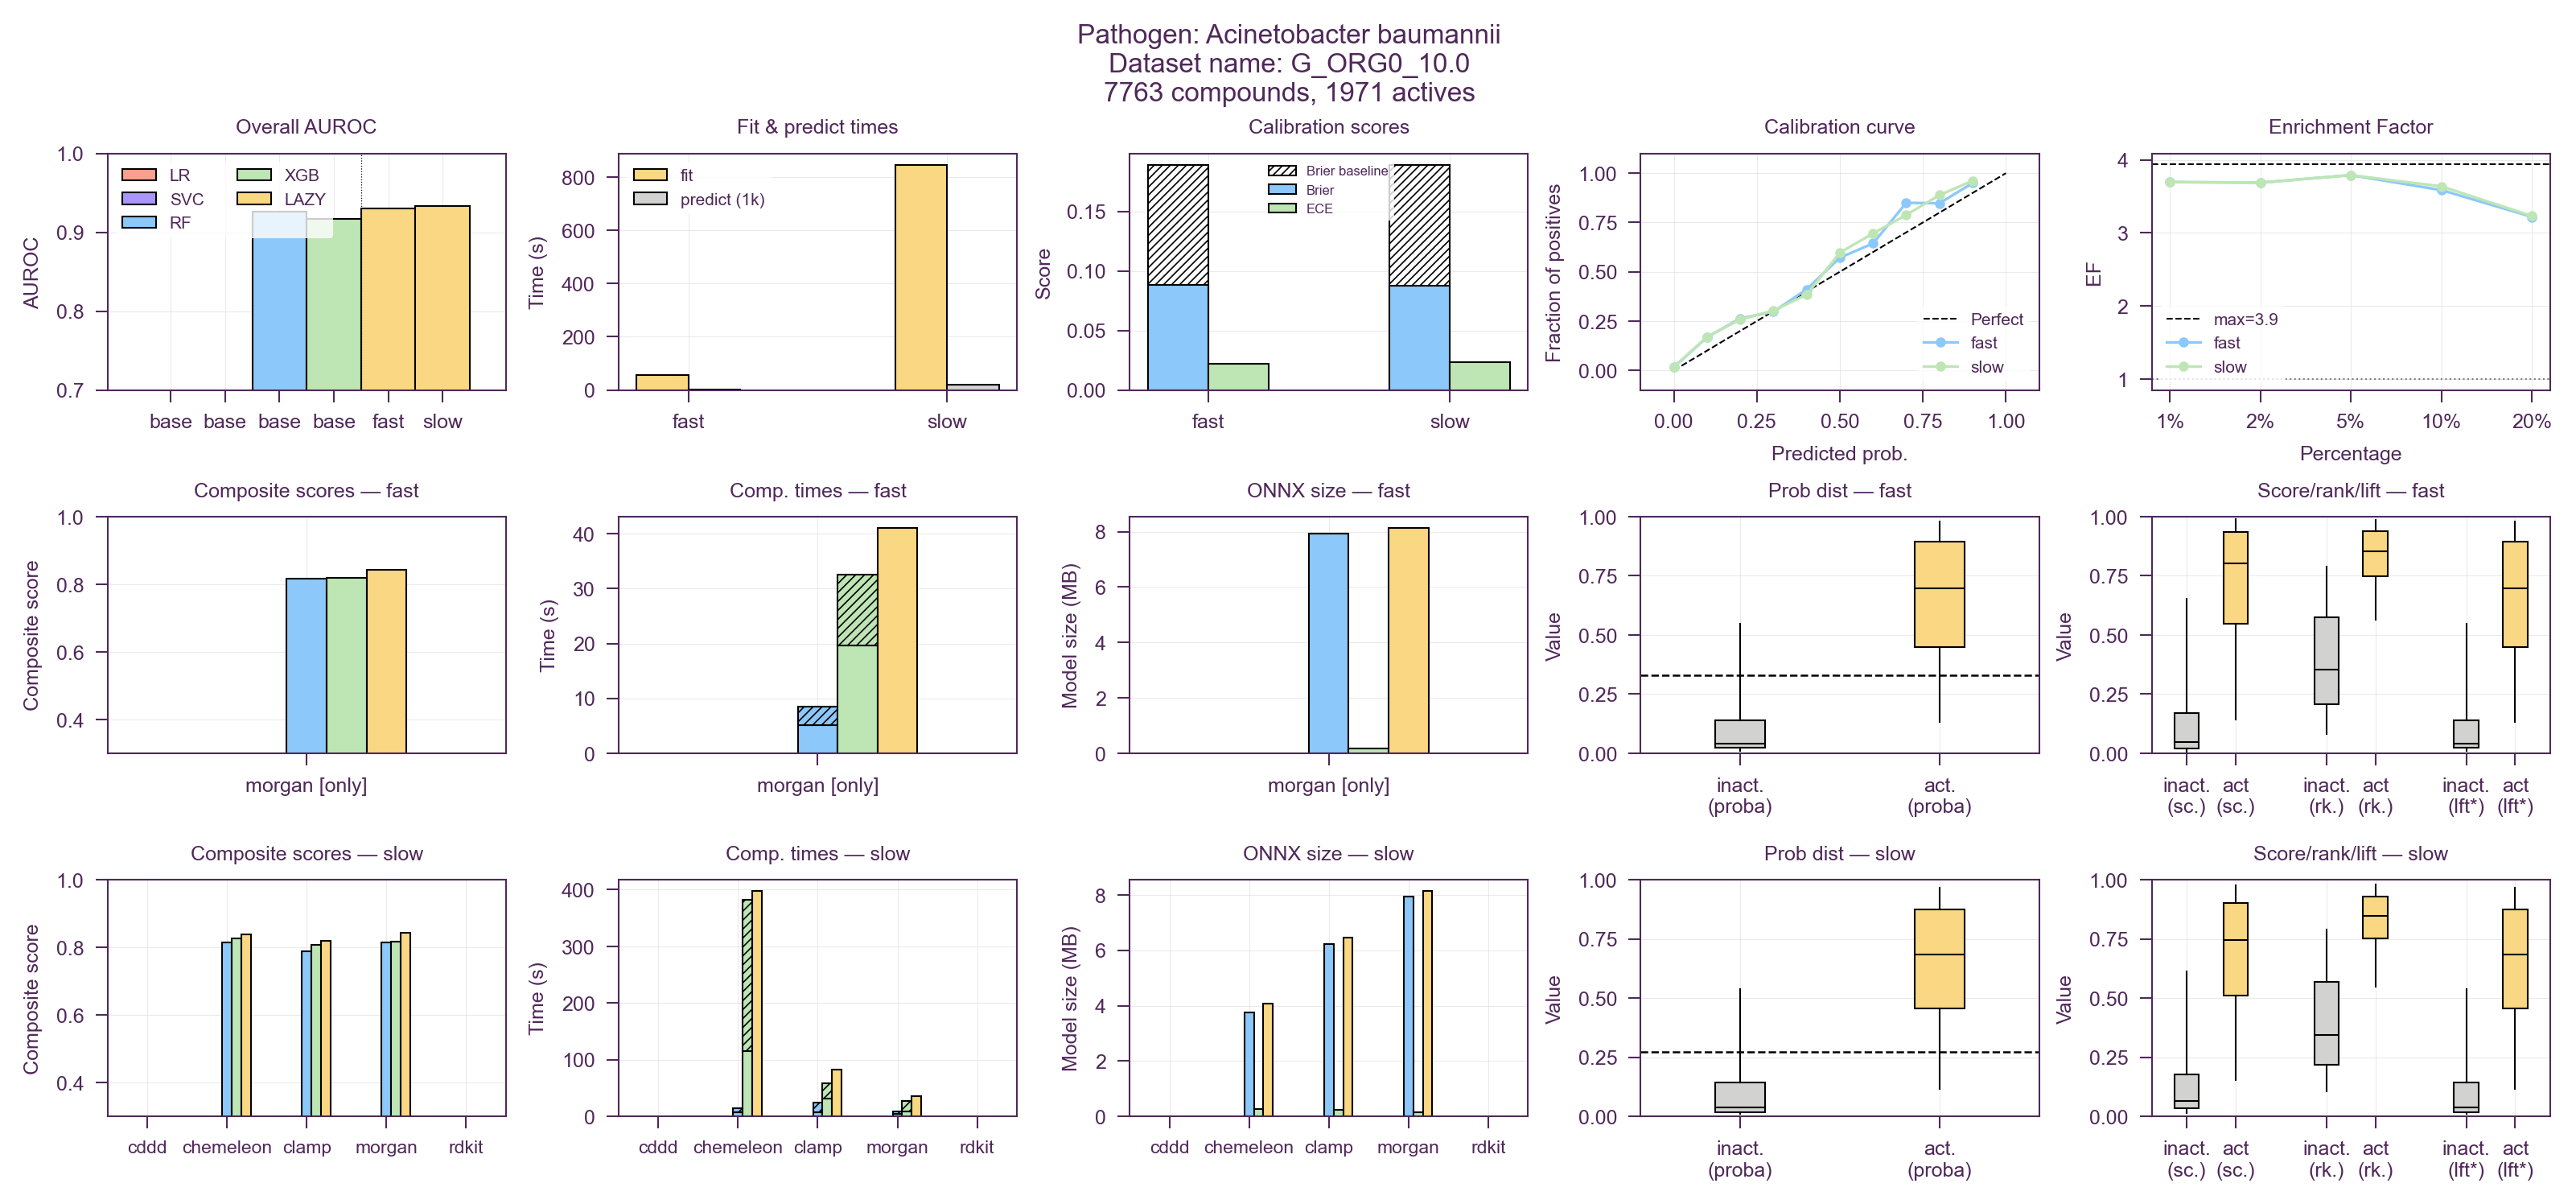

In [28]:
DATASETS = [
    ["calbicans", "G_ORG7_10.0"],
    ["ecoli", "G_ORG7_10.0"],
    ["paeruginosa", "G_ORG5_50.0"],
    ["smansoni", "G_ORG1_10.0"],
    ["abaumannii", "G_ORG0_10.0"],
    # ["calbicans", "G_ORG0_50.0"],
    # ["saureus", "G_ORG6_10.0"],
    # ["mtuberculosis", "G_ORG1_10.0"],
    # ["ecoli", "G_ORG2_10.0"],
    # ["pfalciparum", "CHEMBL1054501_INHIBITION_%_qt_75.0"],
    # ["pfalciparum", "CHEMBL4888485_INHIBITION_%_qt_50.0"],
]

# Layout: 3 rows × 5 columns = create_figure(3, 5)
# Row 1 (summaries): Overall AUROC | Times | Cal scores | Cal curve | EF
# Row 2 (fast):      Composite scores | Comp times | ONNX sizes | Prob dist | Score/rank/lift
# Row 3 (slow):      same as row 2

HEADS_ORDERED = ["lr", "svc", "rf", "xgb"]
HEAD_COLORS = {"lr": nc.orange, "rf": nc.blue, "xgb": nc.mint, "svc": nc.purple}

def _get(row, col):
    v = row.get(col, np.nan)
    return np.nan if (v is None or (isinstance(v, float) and np.isnan(v))) else float(v)

for pathogen, dataset in DATASETS:
    df_subset = df[(df["pathogen"] == pathogen) & (df["dataset"] == dataset)]
    modes = ["fast", "slow"]
    colors_map = {"fast": nc.blue, "slow": nc.mint}

    stylia.set_format("print")

    fig, axs = stylia.create_figure(3, 5, width=1.5, height=0.7)
    actives = df_subset["positives"].values[0]
    compounds = df_subset["compounds"].values[0]
    fig.suptitle(
        f"Pathogen: {pathogen_codes[pathogen]}\nDataset name: {dataset}\n{compounds} compounds, {actives} actives",
        fontsize=stylia.FONTSIZE_BIG,
    )

    ################################################
    ######### ROW 1: SUMMARIES #####################
    ################################################

    # [0] Overall AUROC
    ax = axs.next()
    W = 0.15
    ax.set_title("Overall AUROC")
    ax.set_ylim([0.7, 1])
    ax.set_yticks([0.7, 0.8, 0.9, 1])
    ax.set_ylabel("AUROC")
    baseline_cols = {"LR": "auroc_lr", "SVC": "auroc_svc", "RF": "auroc_rf", "XGB": "auroc_xgb"}
    baseline_colors = {"LR": nc.orange, "RF": nc.blue, "XGB": nc.mint, "SVC": nc.purple}
    n_base = len(baseline_cols)
    xticks = []
    for i, (lbl, col) in enumerate(baseline_cols.items()):
        x_pos = (i - (n_base - 1) / 2) * W
        ax.bar(x_pos, df_subset[df_subset["mode"] == "fast"][col].mean(),
               color=baseline_colors[lbl], width=W, ec="k", lw=0.5, label=lbl)
        xticks.append(x_pos)
    for j, mode in enumerate(modes):
        x_pos = (n_base / 2 + 0.5 + j) * W
        ax.bar(x_pos, df_subset[df_subset["mode"] == mode]["auroc_lazy"].mean(),
               color=nc.yellow, width=W, ec="k", lw=0.5,
               label="LAZY" if j == 0 else "")
        xticks.append(x_pos)
    ax.axvline((n_base / 2) * W, color="k", lw=0.3, ls=":")
    ax.legend(prop={"size": 5}, ncol=2, loc="upper left")
    ax.set_xticks(xticks)
    ax.set_xticklabels(["base", "base", "base", "base", "fast", "slow"], rotation=0)
    ax.set_xlabel("")
    ax.set_xlim([-0.4, 0.7])

    # [1] Fit & predict times
    ax = axs.next()
    W = 0.2
    ax.set_title("Fit & predict times")
    ax.set_ylabel("Time (s)")
    for x, mode in enumerate(modes):
        fit_t = df_subset[df_subset["mode"] == mode]["time_lazyqsar_fit_s"].values[0]
        pred_t = df_subset[df_subset["mode"] == mode]["predict_time_1k_s"].values[0]
        ax.bar(x - W / 2, fit_t, color=nc.yellow, width=W, ec="k", lw=0.5,
               label="fit" if x == 0 else "")
        ax.bar(x + W / 2, pred_t, color=nc.gray, width=W, ec="k", lw=0.5,
               label="predict (1k)" if x == 0 else "")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(modes)
    ax.legend(prop={"size": 5}, loc='upper left')
    ax.set_xlabel("")

    # [2] Calibration scores
    ax = axs.next()
    ax.set_title("Calibration scores")
    W = 0.25
    for x, mode in enumerate(modes):
        row = df_subset[df_subset["mode"] == mode].iloc[0]
        ax.bar(x - W / 2, row["brier_baseline"], color="w", width=W, ec="k", lw=0.5,
               label="Brier baseline" if x == 0 else "", hatch="//" * 5)
        ax.bar(x - W / 2, row["brier_score"], color=nc.blue, width=W, ec="k", lw=0.5,
               label="Brier" if x == 0 else "")
        ax.bar(x + W / 2, row["ece"], color=nc.mint, width=W, ec="k", lw=0.5,
               label="ECE" if x == 0 else "")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(modes)
    ax.set_ylabel("Score")
    ax.legend(prop={"size": 4}, loc='upper center')
    ax.set_xlabel("")

    # [3] Calibration curve
    ax = axs.next()
    ax.set_title("Calibration curve")
    ax.plot([0, 1], [0, 1], "k--", lw=0.5, label="Perfect")
    cal_x = list(np.arange(0, 1, 0.1))
    for mode in modes:
        row = df_subset[df_subset["mode"] == mode].iloc[0]
        cal_y_raw = [float(v) for v in row["calibration_y"].split(";")]
        xs = [x for x, y in zip(cal_x, cal_y_raw) if not np.isnan(y)]
        ys = [y for y in cal_y_raw if not np.isnan(y)]
        ax.plot(xs, ys, color=colors_map[mode], lw=0.8, marker="o", markersize=2, label=mode)
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_xlabel("Predicted prob.")
    ax.set_ylabel("Fraction of positives")
    ax.legend(prop={"size": 5}, loc="lower right")

    # [4] Enrichment factor
    ax = axs.next()
    ax.set_title("Enrichment Factor")
    pcts = [1, 2, 5, 10, 20]
    max_ef = compounds / actives
    ax.axhline(max_ef, color="k", linestyle="--", lw=0.5, label=f"max={max_ef:.1f}")
    for mode in modes:
        row = df_subset[df_subset["mode"] == mode].iloc[0]
        efs = [row[f"ef_{p}pct"] for p in pcts]
        ax.plot(range(len(pcts)), efs, color=colors_map[mode], lw=0.8,
                marker="o", markersize=2, label=mode)
    ax.axhline(1, color="gray", linestyle=":", lw=0.5)
    ax.set_xticks(range(len(pcts)))
    ax.set_xticklabels([f"{p}%" for p in pcts])
    ax.set_ylabel("EF")
    ax.set_xlabel("Percentage")
    ax.legend(prop={"size": 5}, loc='lower left')

    ################################################
    ######### ROWS 2-3: PER-MODE PANELS ############
    ################################################

    for mode in modes:
        descs = ["morgan"] if mode == "fast" else ["cddd", "chemeleon", "clamp", "morgan", "rdkit"]
        row_data = df_subset[df_subset["mode"] == mode].iloc[0]

        # bar layout: n_heads + 1 (pooler/total), W=0.15
        n_items = len(HEADS_ORDERED) + 1
        W = 0.6 / n_items
        offsets = [(i - (n_items - 1) / 2) * W for i in range(n_items)]

        # [0] Composite scores (lr, rf, xgb, svc, pooler)
        ax = axs.next()
        ax.set_title(f"Composite scores — {mode}")
        ax.set_ylim([0.3, 1])
        ax.set_ylabel("Composite score")
        first = True
        for x, desc in enumerate(descs):
            for i, h in enumerate(HEADS_ORDERED):
                val = _get(row_data, f"head_score_{desc}_{h}")
                if not np.isnan(val):
                    ax.bar(x + offsets[i], val, color=HEAD_COLORS[h], width=W, ec="k", lw=0.5,
                           label=h.upper() if first else "")
            pooler_val = _get(row_data, f"pooler_{desc}_score")
            if not np.isnan(pooler_val):
                ax.bar(x + offsets[-1], pooler_val, color=nc.yellow, width=W, ec="k", lw=0.5,
                       label="pooler" if first else "")
            first = False
        ax.set_xlabel("")
        if mode != 'fast':
            ax.set_xticks(range(len(descs)))
            ax.set_xticklabels(descs, rotation=0, fontsize=5.5)
            ax.set_xlim([-0.5, 4.5])
        else:
            ax.set_xticks(range(len(descs)))
            ax.set_xticklabels(['morgan [only]'], rotation=0, fontsize=6)
            ax.set_xlim([-0.6, 0.6])
        
        # [1] Per-descriptor compute times (lr, rf, xgb, svc stacked fit+cal, then total)
        ax = axs.next()
        ax.set_title(f"Comp. times — {mode}")
        ax.set_ylabel("Time (s)")
        first = True
        for x, desc in enumerate(descs):
            for i, h in enumerate(HEADS_ORDERED):
                fit = _get(row_data, f"time_{desc}_{h}_fit_s")
                cal = _get(row_data, f"time_{desc}_{h}_calibration_s")
                if not np.isnan(fit):
                    ax.bar(x + offsets[i], fit, color=HEAD_COLORS[h], width=W, ec="k", lw=0.5,
                           label=h.upper() if first else "")
                if not np.isnan(fit) and not np.isnan(cal) and cal > 0:
                    ax.bar(x + offsets[i], bottom=fit, height=cal, color=HEAD_COLORS[h],
                           width=W, ec="k", lw=0.5, hatch="/////////")
            total = _get(row_data, f"time_{desc}_total_s")
            if not np.isnan(total):
                ax.bar(x + offsets[-1], total, color=nc.yellow, width=W, ec="k", lw=0.5,
                       label="total" if first else "")
            first = False
        ax.set_xlabel("")
        if mode != 'fast':
            ax.set_xticks(range(len(descs)))
            ax.set_xticklabels(descs, rotation=0, fontsize=5.5)
            ax.set_xlim([-0.5, 4.5])
        else:
            ax.set_xticks(range(len(descs)))
            ax.set_xticklabels(['morgan [only]'], rotation=0, fontsize=6)
            ax.set_xlim([-0.6, 0.6])

        # [2] ONNX sizes (lr, rf, xgb, svc, total)
        ax = axs.next()
        ax.set_title(f"ONNX size — {mode}")
        ax.set_ylabel("Model size (MB)")
        first = True
        for x, desc in enumerate(descs):
            for i, h in enumerate(HEADS_ORDERED):
                val = _get(row_data, f"onnx_{desc}_{h}_kb")
                if not np.isnan(val):
                    ax.bar(x + offsets[i], val / 1000, color=HEAD_COLORS[h], width=W, ec="k", lw=0.5,
                           label=h.upper() if first else "")
            total = _get(row_data, f"onnx_{desc}_total_kb")
            if not np.isnan(total):
                ax.bar(x + offsets[-1], total / 1000, color=nc.yellow, width=W, ec="k", lw=0.5,
                       label="total" if first else "")
            first = False
        ax.set_xlabel("")
        if mode != 'fast':
            ax.set_xticks(range(len(descs)))
            ax.set_xticklabels(descs, rotation=0, fontsize=5.5)
            ax.set_xlim([-0.5, 4.5])
        else:
            ax.set_xticks(range(len(descs)))
            ax.set_xticklabels(['morgan [only]'], rotation=0, fontsize=6)
            ax.set_xlim([-0.6, 0.6])

        # [3] Predicted probability distribution
        ax = axs.next()
        stats_inact = dict(med=row_data["prob_inactive_p50"], q1=row_data["prob_inactive_p25"],
                           q3=row_data["prob_inactive_p75"], whislo=row_data["prob_inactive_p5"],
                           whishi=row_data["prob_inactive_p95"], fliers=[])
        stats_act = dict(med=row_data["prob_active_p50"], q1=row_data["prob_active_p25"],
                         q3=row_data["prob_active_p75"], whislo=row_data["prob_active_p5"],
                         whishi=row_data["prob_active_p95"], fliers=[])
        bp = ax.bxp([stats_inact, stats_act], positions=[0, 1], widths=0.25,
                    patch_artist=True, showfliers=False)
        bp["boxes"][0].set_facecolor(nc.gray)
        bp["boxes"][0].set_linewidth(0.5)
        bp["boxes"][1].set_facecolor(nc.yellow)
        bp["boxes"][1].set_linewidth(0.5)
        for element in ["whiskers", "caps", "medians"]:
            for line in bp[element]:
                line.set_color("k")
                line.set_linewidth(0.5)
                if element == "caps":
                    line.set_linewidth(0)
        ax.axhline(row_data["optimal_cutoff"], color="k", linestyle="--", lw=0.6,
                   label=f"cutoff={row_data['optimal_cutoff']:.3f}")
        ax.set_ylim([0, 1])
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["inact.\n(proba)", "act.\n(proba)"])
        ax.set_title(f"Prob dist — {mode}")
        ax.set_ylabel("Value")
        ax.set_xlabel("")

        # [4] Score / rank / lift distributions
        ax = axs.next()
        W_box = 0.35
        for position, predict in zip([0, 2, 4], ["score", "rank", "lift"]):
            stats_inact = dict(med=row_data[f"{predict}_inactive_p50"], q1=row_data[f"{predict}_inactive_p25"],
                               q3=row_data[f"{predict}_inactive_p75"], whislo=row_data[f"{predict}_inactive_p5"],
                               whishi=row_data[f"{predict}_inactive_p95"], fliers=[])
            stats_act = dict(med=row_data[f"{predict}_active_p50"], q1=row_data[f"{predict}_active_p25"],
                             q3=row_data[f"{predict}_active_p75"], whislo=row_data[f"{predict}_active_p5"],
                             whishi=row_data[f"{predict}_active_p95"], fliers=[])
            if predict == "lift":
                max_lift = row_data["compounds"] / row_data["positives"]
                stats_inact = {k: v / max_lift for k, v in stats_inact.items() if k != "fliers"}
                stats_inact["fliers"] = []
                stats_act = {k: v / max_lift for k, v in stats_act.items() if k != "fliers"}
                stats_act["fliers"] = []
            bp = ax.bxp([stats_inact, stats_act], positions=[position, position + W_box * 2],
                        widths=W_box, patch_artist=True, showfliers=False)
            bp["boxes"][0].set_facecolor(nc.gray)
            bp["boxes"][0].set_linewidth(0.5)
            bp["boxes"][1].set_facecolor(nc.yellow)
            bp["boxes"][1].set_linewidth(0.5)
            for element in ["whiskers", "caps", "medians"]:
                for line in bp[element]:
                    line.set_color("k")
                    line.set_linewidth(0.5)
                    if element == "caps":
                        line.set_linewidth(0)
        ax.set_ylim([0, 1])
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xticks([k for i in [0, 2, 4] for k in [i, i + W_box * 2]])
        ax.set_xticklabels(["inact.\n(sc.)", "act\n(sc.)", "inact.\n(rk.)",
                             "act\n(rk.)", "inact.\n(lft*)", "act\n(lft*)"])
        ax.set_title(f"Score/rank/lift — {mode}")
        ax.set_ylabel("Value")
        ax.set_xlabel("")

    plt.tight_layout()
    plt.show()